# EDA — Dataset de Trincas e Fissuras

Análise exploratória do dataset antes do treinamento.
Cobre: contagem, resoluções, formato dos labels, distribuição de classes e tamanho dos objetos.

In [22]:
import os
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# Resolve o root do projeto independente de onde o kernel foi iniciado
_here = Path.cwd()
if _here.name == "notebooks":
    _root = _here.parent          # desafio2_trincas/
else:
    _root = _here                 # ja esta em desafio2_trincas/

IMG_DIR = _root.parent / "dataset" / "images"
LBL_DIR = _root.parent / "dataset" / "labels"
RESULTS_DIR = _root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Confirma que os diretorios existem
assert IMG_DIR.exists(), f"Nao encontrado: {IMG_DIR}"
assert LBL_DIR.exists(), f"Nao encontrado: {LBL_DIR}"

print(f"Dataset : {IMG_DIR}")
print(f"Labels  : {LBL_DIR}")
print(f"Results : {RESULTS_DIR}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Dataset : c:\Users\Carla Batista\Desktop\Desafio-2\dataset\images
Labels  : c:\Users\Carla Batista\Desktop\Desafio-2\dataset\labels
Results : c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results


## 1. Contagem e extensões

In [23]:
images = sorted(IMG_DIR.glob('*.jpg')) + sorted(IMG_DIR.glob('*.png'))
labels = sorted(LBL_DIR.glob('*.txt'))

img_stems = {p.stem for p in images}
lbl_stems = {p.stem for p in labels}

print(f'Imagens : {len(images)}')
print(f'Labels  : {len(labels)}')
print(f'Pares   : {len(img_stems & lbl_stems)}')
print(f'Órfãos img: {len(img_stems - lbl_stems)}')
print(f'Órfãos lbl: {len(lbl_stems - img_stems)}')

Imagens : 1551
Labels  : 1551
Pares   : 1551
Órfãos img: 0
Órfãos lbl: 0


## 2. Resolução das imagens

In [24]:
from collections import Counter

sample = random.sample(images, min(200, len(images)))
resolutions = Counter()
for p in sample:
    img = Image.open(p)
    resolutions[img.size] += 1

print('Resoluções encontradas (amostra de 200):')
for res, cnt in resolutions.most_common():
    print(f'  {res[0]}x{res[1]}: {cnt} imagens')

Resoluções encontradas (amostra de 200):
  2560x1440: 200 imagens


## 3. Análise dos labels — formato e classes

In [25]:
class_counts   = Counter()
obj_per_image  = []
point_counts   = []
bbox_widths    = []
bbox_heights   = []
aspect_ratios  = []   # largura / altura da bbox derivada do polígono

for lbl_path in labels:
    lines = [l.strip() for l in lbl_path.read_text().splitlines() if l.strip()]
    obj_per_image.append(len(lines))
    for line in lines:
        parts = line.split()
        cls   = int(parts[0])
        class_counts[cls] += 1
        coords = np.array(parts[1:], dtype=float)
        n_pts  = len(coords) // 2
        point_counts.append(n_pts)
        xs = coords[0::2]
        ys = coords[1::2]
        w  = xs.max() - xs.min()
        h  = ys.max() - ys.min()
        bbox_widths.append(w)
        bbox_heights.append(h)
        aspect_ratios.append(w / h if h > 0 else 0)

print('Classes:', dict(class_counts))
print(f'\nObjetos por imagem:')
print(f'  min={min(obj_per_image)}  max={max(obj_per_image)}  média={np.mean(obj_per_image):.2f}')
print(f'\nPontos por polígono:')
print(f'  min={min(point_counts)}  max={max(point_counts)}  média={np.mean(point_counts):.1f}')
print(f'\nTamanho normalizado das bboxes:')
print(f'  largura  — min={min(bbox_widths):.3f}  max={max(bbox_widths):.3f}  média={np.mean(bbox_widths):.3f}')
print(f'  altura   — min={min(bbox_heights):.3f}  max={max(bbox_heights):.3f}  média={np.mean(bbox_heights):.3f}')

Classes: {0: 2056}

Objetos por imagem:
  min=1  max=18  média=1.33

Pontos por polígono:
  min=4  max=796  média=135.0

Tamanho normalizado das bboxes:
  largura  — min=0.004  max=1.000  média=0.346
  altura   — min=0.006  max=1.000  média=0.608


## 4. Distribuição de objetos por imagem

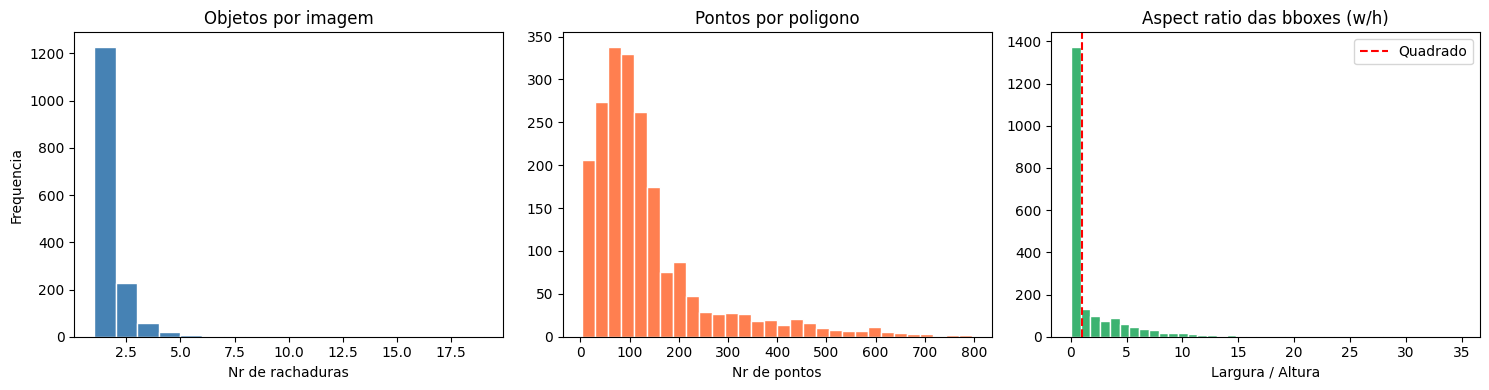

Salvo em: c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_distributions.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(obj_per_image, bins=range(1, max(obj_per_image)+2), color='steelblue', edgecolor='white')
axes[0].set_title('Objetos por imagem')
axes[0].set_xlabel('Nr de rachaduras')
axes[0].set_ylabel('Frequencia')

axes[1].hist(point_counts, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Pontos por poligono')
axes[1].set_xlabel('Nr de pontos')

axes[2].hist(aspect_ratios, bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Aspect ratio das bboxes (w/h)')
axes[2].set_xlabel('Largura / Altura')
axes[2].axvline(1.0, color='red', linestyle='--', label='Quadrado')
axes[2].legend()

plt.tight_layout()
out = RESULTS_DIR / 'eda_distributions.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 5. Mapa de calor dos centros das bboxes

Revela se há viés de posição (ex.: trincas concentradas no centro das imagens).

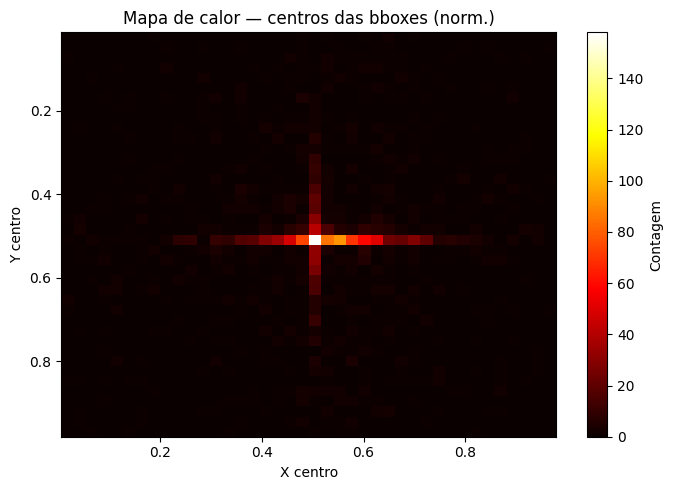

Salvo em: c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_heatmap.png


In [27]:
cx_list = []
cy_list = []

for lbl_path in labels:
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        coords = np.array(parts[1:], dtype=float)
        xs = coords[0::2]
        ys = coords[1::2]
        cx_list.append((xs.max() + xs.min()) / 2)
        cy_list.append((ys.max() + ys.min()) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(cx_list, cy_list, bins=40, cmap='hot')
plt.colorbar(h[3], ax=ax, label='Contagem')
ax.set_title('Mapa de calor — centros das bboxes (norm.)')
ax.set_xlabel('X centro')
ax.set_ylabel('Y centro')
ax.invert_yaxis()
plt.tight_layout()
out = RESULTS_DIR / 'eda_heatmap.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 6. Scatter: largura × altura das bboxes

Trincas costumam ser objetos finos e alongados — esperamos pontos concentrados próximos aos eixos.

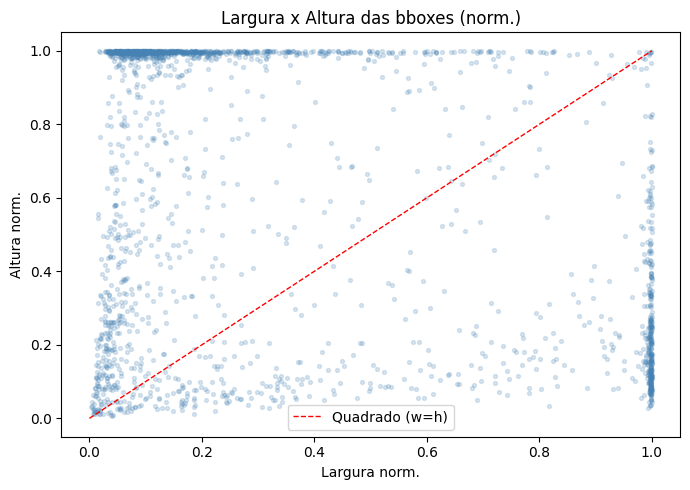

Salvo em: c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_bbox_scatter.png


In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bbox_widths, bbox_heights, alpha=0.2, s=8, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Quadrado (w=h)')
ax.set_title('Largura x Altura das bboxes (norm.)')
ax.set_xlabel('Largura norm.')
ax.set_ylabel('Altura norm.')
ax.legend()
plt.tight_layout()
out = RESULTS_DIR / 'eda_bbox_scatter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 7. Visualização de amostras com polígonos sobrepostos

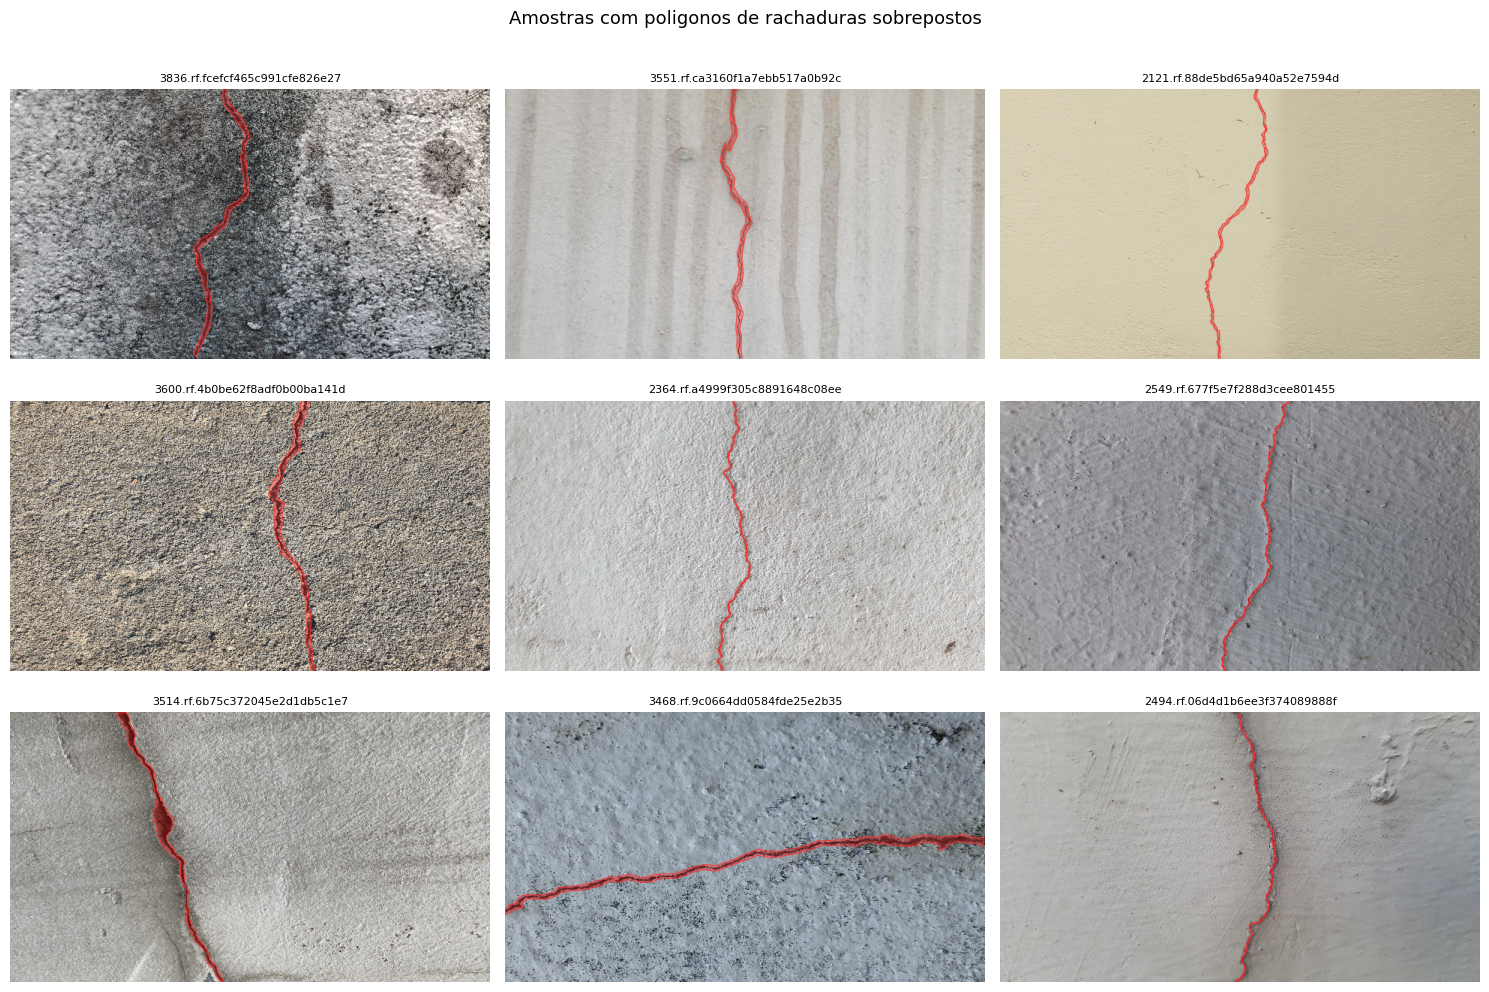

Salvo em: c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_samples.png


In [29]:
def draw_polygons(img_path: Path, lbl_path: Path) -> np.ndarray:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        coords = np.array(parts[1:], dtype=float)
        pts = coords.reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)
        cv2.fillPoly(overlay, [pts], color=(255, 50, 50))
        cv2.polylines(img, [pts], isClosed=True, color=(255, 50, 50), thickness=3)

    return cv2.addWeighted(overlay, 0.35, img, 0.65, 0)


stems = sorted(img_stems & lbl_stems)
sample_stems = random.sample(stems, 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, stem in zip(axes.flat, sample_stems):
    vis = draw_polygons(IMG_DIR / f'{stem}.jpg', LBL_DIR / f'{stem}.txt')
    vis_small = cv2.resize(vis, (640, 360))
    ax.imshow(vis_small)
    ax.set_title(stem[:30], fontsize=8)
    ax.axis('off')

plt.suptitle('Amostras com poligonos de rachaduras sobrepostos', fontsize=13, y=1.01)
plt.tight_layout()
out = RESULTS_DIR / 'eda_samples.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 8. Resumo — decisões tomadas com base no EDA

| Observação | Impacto / Decisão |
|---|---|
| Labels em formato YOLO-seg (polígonos) | Usar `yolo11n-seg.pt` — segmentação de instâncias |
| 1 única classe (`rachadura`) | `nc=1` no `data.yaml` |
| Polígonos com até 212 pontos (média ~72) | Rachaduras têm formato irregular — bbox seria imprecisa |
| 1551 imagens, todas 2560×1440 | Dataset pequeno-médio; `imgsz=640` no treino |
| Média 1.33 objetos/imagem | Dataset relativamente simples; overfitting é risco |
| Split 70/20/10 com seed 42 | Val com 310 imgs dá mAP confiável |

---
## 9. Teste do Modelo Treinado

Carrega o modelo e roda inferência em imagens do test set.  
Troque `MODEL_PATH` para comparar v1 vs v3.

In [30]:
from ultralytics import YOLO

# Troque aqui para testar versoes diferentes:
#   'best_crack_seg_yolo11n.pt'  → v1 (640px, 100 ep)
#   'best_v3_nano_1280.pt'       → v3 (1280px, 150 ep)
MODEL_PATH = _root / "models" / "best_v3_nano_1280.pt"

model = YOLO(str(MODEL_PATH))
print(f"Modelo carregado: {MODEL_PATH.name}")
print(f"Classes: {model.names}")
print(f"Tarefa : {model.task}")

Modelo carregado: best_v3_nano_1280.pt
Classes: {0: 'rachadura'}
Tarefa : segment


### 9.1 Inferência em imagens aleatórias do test set

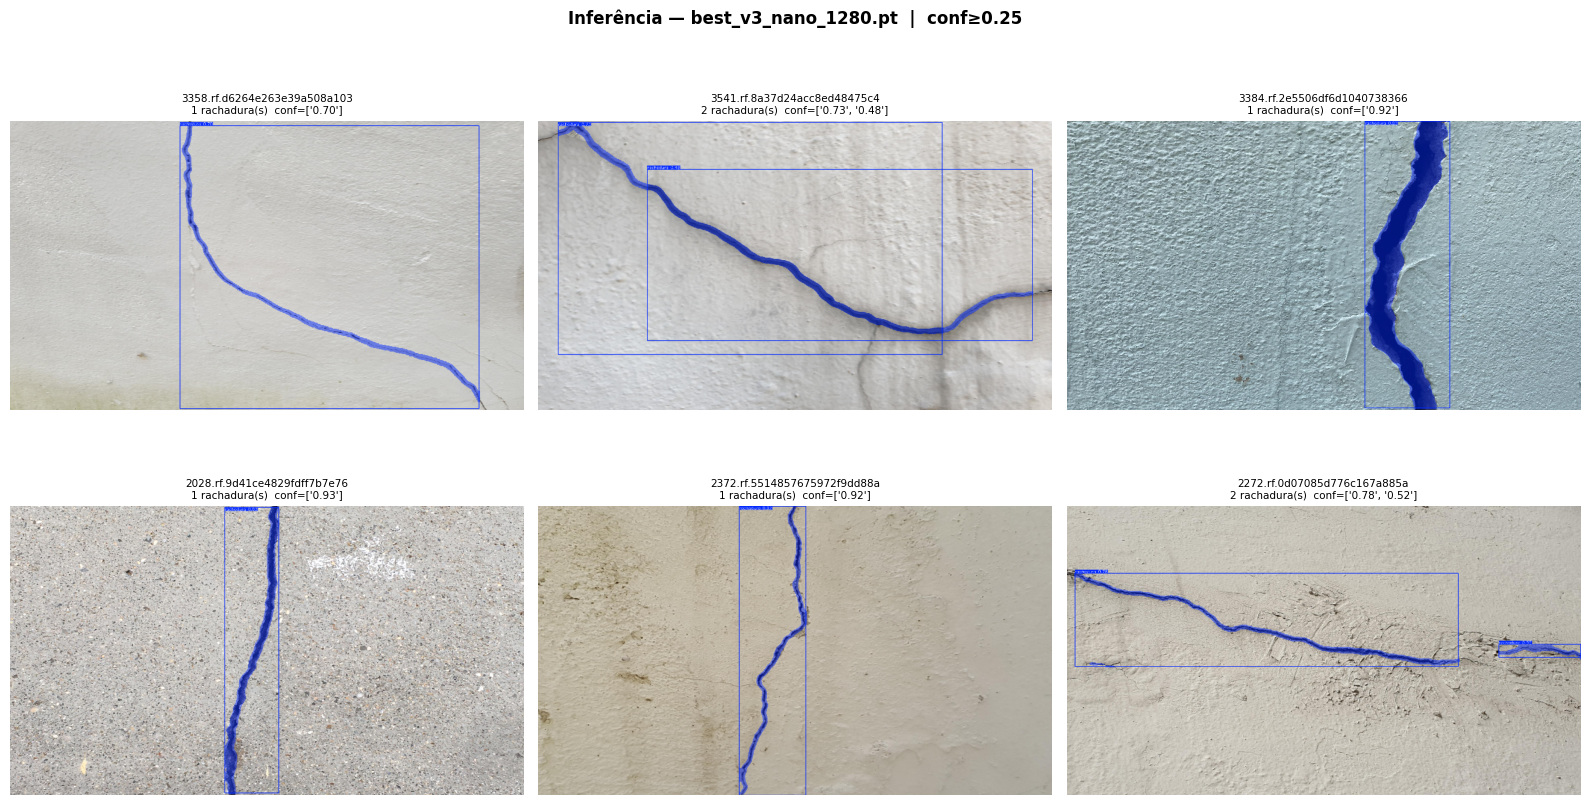

Imagem salva em results/inferencia_notebook.png


In [31]:
TEST_DIR  = _root / "data" / "dataset_split" / "test" / "images"
CONF      = 0.25   # limiar de confiança — tente 0.15 para mais recall
IOU       = 0.50
N_AMOSTRAS = 6     # quantas imagens exibir

test_imgs = sorted(TEST_DIR.glob("*.jpg"))
amostra   = random.sample(test_imgs, N_AMOSTRAS)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flat, amostra):
    results = model.predict(
        source  = str(img_path),
        conf    = CONF,
        iou     = IOU,
        imgsz   = 1280,   # use 640 se testar o modelo v1
        device  = 0,      # use 'cpu' se nao tiver GPU
        verbose = False,
    )[0]

    # plot() retorna BGR — converte para RGB
    img_ann = cv2.cvtColor(results.plot(line_width=2), cv2.COLOR_BGR2RGB)
    img_ann = cv2.resize(img_ann, (853, 480))

    n_det = len(results.boxes)
    confs = [f"{float(c):.2f}" for c in results.boxes.conf] if n_det else []

    ax.imshow(img_ann)
    ax.set_title(f"{img_path.name[:28]}\n{n_det} rachadura(s)  conf={confs}", fontsize=7.5)
    ax.axis("off")

plt.suptitle(f"Inferência — {MODEL_PATH.name}  |  conf≥{CONF}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "inferencia_notebook.png", dpi=120, bbox_inches="tight")
plt.show()
print("Imagem salva em results/inferencia_notebook.png")

### 9.2 Testar em uma imagem específica (sua foto)

Testando: c:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\data\dataset_split\test\images\1686.rf.5333e8ce36e6056914fd87b5e7b89582.jpg


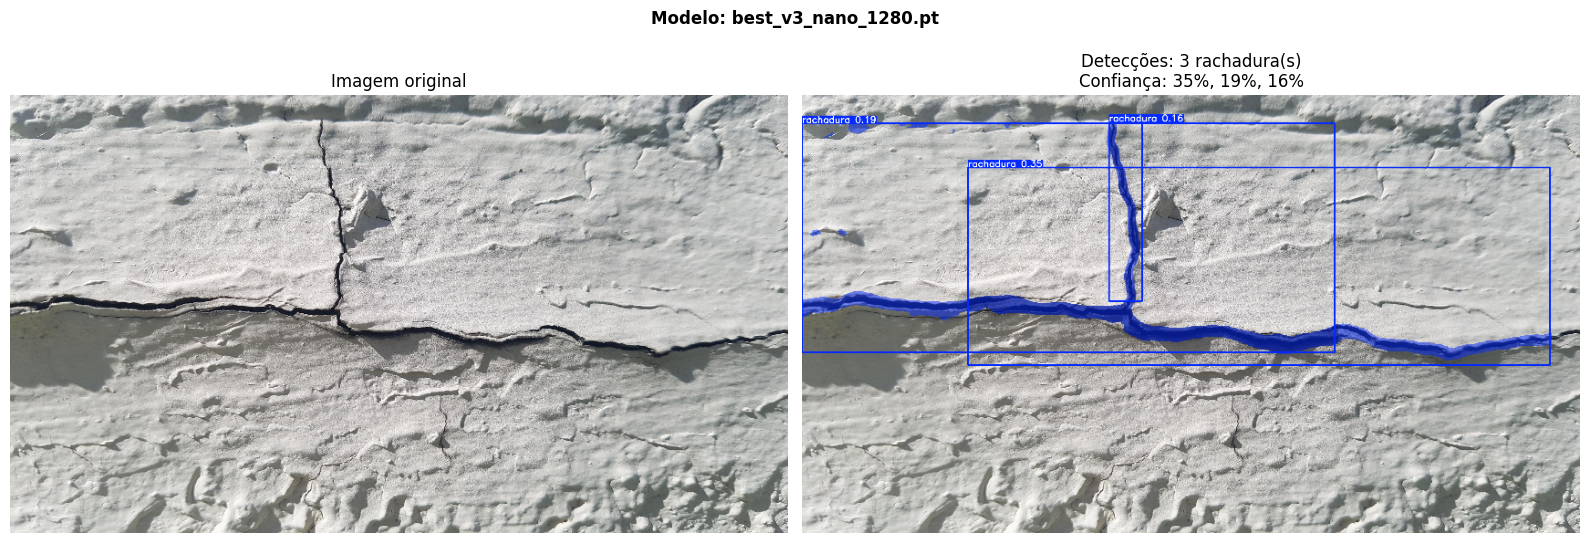

In [32]:
# Cole aqui o caminho de qualquer imagem sua para testar
MINHA_IMAGEM = r"C:\caminho\para\sua\foto.jpg"   # <-- edite aqui

# --- ou use uma imagem do dataset para testar ---
MINHA_IMAGEM = str(random.choice(test_imgs))
print(f"Testando: {MINHA_IMAGEM}")

results = model.predict(
    source  = MINHA_IMAGEM,
    conf    = 0.15,    # mais sensível para não perder rachaduras finas
    iou     = 0.45,
    imgsz   = 1280,
    device  = 0,
    verbose = False,
)[0]

img_ann = cv2.cvtColor(results.plot(line_width=3, font_size=14), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
original = cv2.cvtColor(cv2.imread(MINHA_IMAGEM), cv2.COLOR_BGR2RGB)
axes[0].imshow(cv2.resize(original, (853, 480)))
axes[0].set_title("Imagem original", fontsize=12)
axes[0].axis("off")

# Resultado
axes[1].imshow(cv2.resize(img_ann, (853, 480)))
n = len(results.boxes)
confs = [f"{float(c):.0%}" for c in results.boxes.conf] if n else ["—"]
axes[1].set_title(f"Detecções: {n} rachadura(s)\nConfiança: {', '.join(confs)}", fontsize=12)
axes[1].axis("off")

plt.suptitle(f"Modelo: {MODEL_PATH.name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.3 Comparação v1 vs v3 lado a lado

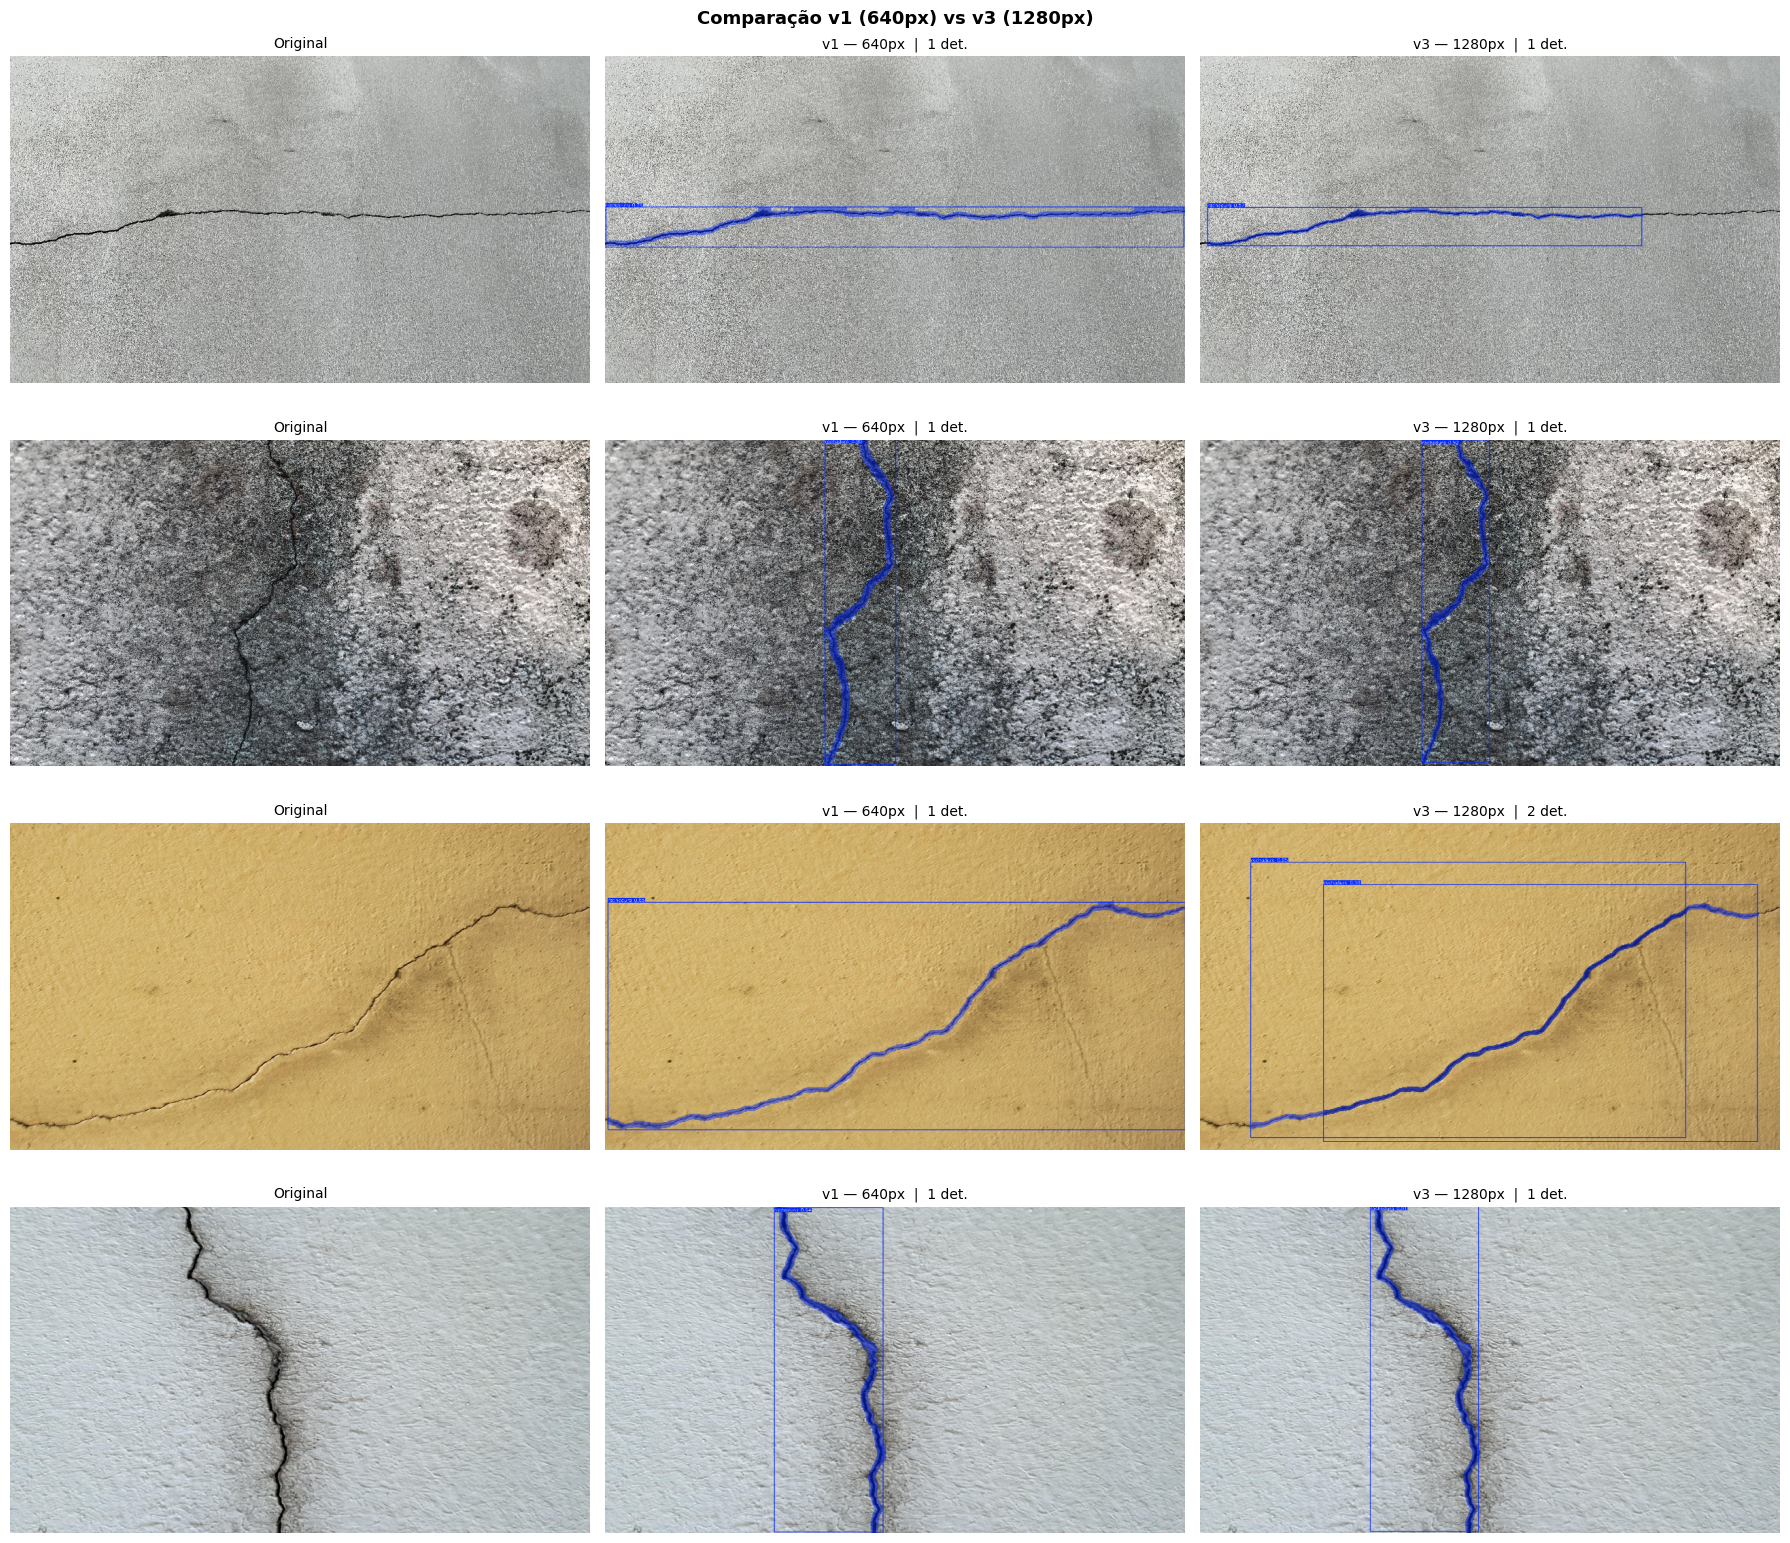

: 

In [ ]:
model_v1 = YOLO(str(_root / "models" / "best_crack_seg_yolo11n.pt"))
model_v3 = YOLO(str(_root / "models" / "best_v3_nano_1280.pt"))

n_imgs = 4
amostra_comp = random.sample(test_imgs, n_imgs)

fig, axes = plt.subplots(n_imgs, 3, figsize=(18, n_imgs * 4))
if n_imgs == 1:
    axes = [axes]

for row, img_path in enumerate(amostra_comp):
    img_bgr = cv2.imread(str(img_path))

    r1 = model_v1.predict(img_bgr, conf=0.25, imgsz=640,  device=0, verbose=False)[0]
    r3 = model_v3.predict(img_bgr, conf=0.25, imgsz=1280, device=0, verbose=False)[0]

    original  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ann_v1    = cv2.cvtColor(r1.plot(line_width=2), cv2.COLOR_BGR2RGB)
    ann_v3    = cv2.cvtColor(r3.plot(line_width=2), cv2.COLOR_BGR2RGB)

    size = (853, 480)
    for col, (img, titulo) in enumerate([
        (original, "Original"),
        (ann_v1, f"v1 — 640px  |  {len(r1.boxes)} det."),
        (ann_v3, f"v3 — 1280px  |  {len(r3.boxes)} det."),
    ]):
        axes[row][col].imshow(cv2.resize(img, size))
        axes[row][col].set_title(titulo, fontsize=10)
        axes[row][col].axis("off")

plt.suptitle("Comparação v1 (640px) vs v3 (1280px)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparacao_modelos_notebook.png", dpi=100, bbox_inches="tight")
plt.show()